In [1]:
# !pip install -q albumentations kaggle

In [2]:
#на kaggle надо найти Legacy API Credentials, создай его и скачай - должен быть файл с названием kaggle.json
#грузани его сюда, это нужно для выгрузки датасета не с локалки, а прям оттуда
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
#грузим датасет
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ml-intensive-yandex-academy-spring-2026

!unzip -q ml-intensive-yandex-academy-spring-2026.zip


100% 2.49G/2.49G [00:19<00:00, 136MB/s]



In [4]:
import os
#чек
print("Содержимое папки:")
print(os.listdir('.'))


Содержимое папки:
['.config', 'dataset', 'ml-intensive-yandex-academy-spring-2026.zip', 'kaggle.json', 'sample_data']


In [5]:
#разархивируем папку
!unzip -l ml-intensive-yandex-academy-spring-2026.zip | head -20

Archive:  ml-intensive-yandex-academy-spring-2026.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
    41900  2026-03-30 13:13   dataset/test_images/0.jpg
    48055  2026-03-30 13:13   dataset/test_images/1.jpg
    53002  2026-03-30 13:13   dataset/test_images/10.jpg
    44000  2026-03-30 13:13   dataset/test_images/100.jpg
    51100  2026-03-30 13:13   dataset/test_images/1000.jpg
    52768  2026-03-30 13:13   dataset/test_images/1001.jpg
    40501  2026-03-30 13:13   dataset/test_images/1002.jpg
    53735  2026-03-30 13:13   dataset/test_images/1003.jpg
    54491  2026-03-30 13:13   dataset/test_images/1004.jpg
    37662  2026-03-30 13:13   dataset/test_images/1005.jpg
    47771  2026-03-30 13:13   dataset/test_images/1006.jpg
    36721  2026-03-30 13:13   dataset/test_images/1007.jpg
    42780  2026-03-30 13:13   dataset/test_images/1008.jpg
    42117  2026-03-30 13:13   dataset/test_images/1009.jpg
    44166  2026-03-30 13:13   dataset/test_images/101.jpg
 

In [6]:
#тест/контроль
class Config:
    TRAIN_IMG_PATH = 'dataset/train_images/'
    TEST_IMG_PATH = 'dataset/test_images/'
    TRAIN_LABELS_PATH = 'dataset/train_solution.csv'

    IMG_SIZE = 256
    BATCH_SIZE = 32
    EPOCHS = 20
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    VAL_SIZE = 0.15
    USE_WEIGHTED_LOSS = True
    SEED = 42  # фиксируем seed для воспроизводимости
    MODEL_SAVE_PATH = 'best_model.pth'  # путь сохранения весов


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import pandas as pd
import numpy as np
from PIL import Image
import os
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # отключаем для полной воспроизводимости

set_seed(Config.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #если есть gpu
print(f"Device: {device}")
print(f"Seed: {Config.SEED}")


Device: cuda
Seed: 42


In [8]:
class DeepfakeDataset(Dataset):
    def __init__(self, image_paths, labels=None, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform  #аугментации

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]  #путь к картинке
        image = Image.open(img_path).convert('RGB')  #переводим BGR в RGB
        image = np.array(image)

        if self.transform:
            transformed = self.transform(image=image)  #аугментации
            image = transformed['image']

        if self.labels is not None:
            label = self.labels[idx]
            return image, label
        return image

In [9]:
def get_train_transforms():
  #compose объединяет несколько трансформаций
    return A.Compose([
        A.HorizontalFlip(p=0.5),   #случайно отражает изображение
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5), #меняет яркость и контраст
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.OneOf([
            A.MotionBlur(blur_limit=3, p=1.0),
            A.MedianBlur(blur_limit=3, p=1.0),
            A.GaussianBlur(blur_limit=3, p=1.0),
        ], p=0.3),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()  #перевод в тензор
    ])

## Архитектура модели

За основу взяли **ResNet18** — сеть с остаточными соединениями, хорошо зарекомендовавшая себя в задачах классификации изображений. Чтобы не просто использовать готовую архитектуру "из коробки", мы добавили в каждый residual-блок **Squeeze-and-Excitation (SE) механизм** — лёгкий attention по каналам признаков. Идея: сеть сама учится, какие каналы важны для данного входа, и масштабирует их соответственно. Это практически не увеличивает количество параметров, но на практике даёт заметный прирост качества (статья Hu et al., 2018).

Дополнительно:
- **Двухслойный классификатор** с Dropout и ReLU вместо одного линейного слоя
- **Взвешенная функция потерь BCEWithLogitsLoss** для борьбы с дисбалансом классов
- **Cosine Annealing LR scheduler** — постепенно снижает learning rate без резких скачков


In [10]:
# SE-блок (Squeeze-and-Excitation)
# добавляем channel attention к каждому residual-блоку реснет-18
# сеть сама учится взвешивать каналы: типа важные усиливаются, шумные подавляются
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        #squeeze: глобальный пул -> делает вектор [B, C]
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        # excitation - два линейных слоя
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        # глобальный average pool по пространственным измерениям
        s = self.squeeze(x).view(b, c)
        # веса для каждого канала
        e = self.excitation(s).view(b, c, 1, 1)
        # перемасштабируем
        return x * e.expand_as(x)


# обёртка
# не будем исходный код ResNet менять, просто оборачиваем каждый BasicBlock
class SEBasicBlock(nn.Module):
    def __init__(self, basic_block, channels):
        super(SEBasicBlock, self).__init__()
        self.block = basic_block
        self.se = SEBlock(channels)

    def forward(self, x):
        out = self.block(x)   # обычный residual forward
        out = self.se(out)    # применяем channel attention
        return out


class DeepfakeResNet18(nn.Module):
    def __init__(self, pretrained=True, dropout_rate=0.5): #хз, возьмём дропаут 0.5 по дефолту, чтоб не сильно предвзятая моделька была
        super(DeepfakeResNet18, self).__init__()
        self.resnet = models.resnet18(pretrained=pretrained)  #сначала брали тупо готовую модель ResNet18 (решили попробовать на 18 слоёв, но есть и больше)

        # внедряем тут SE-блоки в каждый residual-блок всех четырёх слоёв
        # channel counts берём из стандартной ResNet18: [64, 128, 256, 512]
        se_channels = [64, 128, 256, 512]
        for layer_idx, (layer_name, channels) in enumerate(
            zip(['layer1', 'layer2', 'layer3', 'layer4'], se_channels)
        ):
            layer = getattr(self.resnet, layer_name)
            new_blocks = nn.Sequential(*[
                SEBasicBlock(block, channels) for block in layer
            ])
            setattr(self.resnet, layer_name, new_blocks)

        num_features = self.resnet.fc.in_features   #кол-во входных признаков у последнего слоя
        self.resnet.fc = nn.Sequential(
        #тут заменяем последний слой
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        return self.resnet(x)


# чек размер выхода и количество параметров
_model_test = DeepfakeResNet18(pretrained=False)
_dummy = torch.zeros(2, 3, 256, 256)
_out = _model_test(_dummy)
total_params = sum(p.numel() for p in _model_test.parameters())
trainable_params = sum(p.numel() for p in _model_test.parameters() if p.requires_grad)
print(f"Output shape: {_out.shape}  (expected [2, 1])")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
del _model_test, _dummy, _out


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Output shape: torch.Size([2, 1])  (expected [2, 1])
Total params:     11,526,721
Trainable params: 11,526,721


In [11]:
#посмотрим баланс классов (в задаче писали про это)
def calculate_class_weights(labels):
    unique, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    weights = total / (len(unique) * counts)    #веса классов
    return torch.FloatTensor(weights).to(device)

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc='Training')
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        progress_bar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)

    return epoch_loss, f1, recall, precision

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Validation')
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.float().to(device)
            outputs = model(images).squeeze() #предсказания
            loss = criterion(outputs, labels) #функция потерь
            running_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            progress_bar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)

    return epoch_loss, f1, recall, precision #cразу будем выводить все интересующие метрики


In [12]:
#обучаем этого монстра
def train_model():
    train_df = pd.read_csv(Config.TRAIN_LABELS_PATH, header=None, names=['Id', 'target_feature']) #Загружаем таблицу с метками
    train_df['image_path'] = train_df['Id'].apply(
        lambda x: os.path.join(Config.TRAIN_IMG_PATH, f"{x}.jpg") #создаем полный путь до каждого изображения
    )

    print(f"Class distribution:\n{train_df['target_feature'].value_counts()}")

    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_df['image_path'].values,
        train_df['target_feature'].values,
        test_size=Config.VAL_SIZE,
        random_state=Config.SEED,
        stratify=train_df['target_feature'].values
    ) #делим данные на train и validation

    print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")

    train_dataset = DeepfakeDataset(train_paths, train_labels, get_train_transforms())  #тут применяем аугментации
    val_dataset = DeepfakeDataset(val_paths, val_labels, get_val_transforms())

     #создаем батчи
    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True, #валидацию не мешаем
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = DeepfakeResNet18(pretrained=True, dropout_rate=0.5).to(device)
    #считаем веса, чтобы модель не игнорировала редкий класс
    if Config.USE_WEIGHTED_LOSS:
        class_weights = calculate_class_weights(train_labels)
        pos_weight = class_weights[1] / class_weights[0]
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print(f"Using weighted loss: {pos_weight:.4f}")
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=Config.LEARNING_RATE,
        weight_decay=Config.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=Config.EPOCHS,
        eta_min=1e-6
    )

    best_f1 = 0.0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': [],
        'train_recall': [], 'val_recall': [],
        'train_precision': [], 'val_precision': [],
        'lr': []  # следим за learning rate
    }

    for epoch in range(Config.EPOCHS):
        print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")

        train_loss, train_f1, train_recall, train_precision = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_f1, val_recall, val_precision = validate_epoch(
            model, val_loader, criterion, device
        )

        current_lr = optimizer.param_groups[0]['lr']  # текущий lr перед шагом
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['train_recall'].append(train_recall)
        history['val_recall'].append(val_recall)
        history['train_precision'].append(train_precision)
        history['val_precision'].append(val_precision)
        history['lr'].append(current_lr)

        print(f"Train - Loss: {train_loss:.4f}, F1: {train_f1:.4f}, "
              f"Recall: {train_recall:.4f}, Precision: {train_precision:.4f}")
        print(f"Val - Loss: {val_loss:.4f}, F1: {val_f1:.4f}, "
              f"Recall: {val_recall:.4f}, Precision: {val_precision:.4f}")
        print(f"LR: {current_lr:.2e}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            # сохраняем не только веса, но и метаданные эксперимента
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_f1': best_f1,
                'config': {
                    'seed': Config.SEED,
                    'lr': Config.LEARNING_RATE,
                    'batch_size': Config.BATCH_SIZE,
                    'epochs': Config.EPOCHS,
                    'dropout': 0.5,
                    'architecture': 'ResNet18 + SE blocks'
                }
            }
            torch.save(checkpoint, Config.MODEL_SAVE_PATH)
            print(f"✓ Checkpoint saved! Val F1: {best_f1:.4f}")

    print(f"\nBest Val F1: {best_f1:.4f}")
    return model, history

model, history = train_model()


Class distribution:
target_feature
0    41500
1     8500
Name: count, dtype: int64
Train: 42500, Val: 7500
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_11608/4252338087.py:7: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/tmp/ipykernel_11608/4252338087.py:13: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be 

Using weighted loss: 4.8824

Epoch 1/20


Validation: 100%|██████████| 235/235 [00:19<00:00, 12.06it/s, loss=0.766]


Train - Loss: 0.8400, F1: 0.4992, Recall: 0.7518, Precision: 0.3736
Val - Loss: 0.5480, F1: 0.7108, Recall: 0.7961, Precision: 0.6420
LR: 1.00e-04
✓ Checkpoint saved! Val F1: 0.7108

Epoch 2/20


...

Train - Loss: 0.1277, F1: 0.9130, Recall: 0.9722, Precision: 0.8607
Val - Loss: 0.1348, F1: 0.9524, Recall: 0.9655, Precision: 0.9397
LR: 6.40e-06
✓ Checkpoint saved! Val F1: 0.9524

Epoch 19/20


Validation: 100%|██████████| 235/235 [00:18<00:00, 12.60it/s, loss=1.66]


Train - Loss: 0.1198, F1: 0.9192, Recall: 0.9718, Precision: 0.8720
Val - Loss: 0.1544, F1: 0.9576, Recall: 0.9561, Precision: 0.9591
LR: 3.42e-06
✓ Checkpoint saved! Val F1: 0.9576

Epoch 20/20


Validation: 100%|██████████| 235/235 [00:18<00:00, 12.53it/s, loss=1.62]


Train - Loss: 0.1204, F1: 0.9168, Recall: 0.9713, Precision: 0.8680
Val - Loss: 0.1503, F1: 0.9560, Recall: 0.9553, Precision: 0.9568
LR: 1.61e-06

Best Val F1: 0.9576


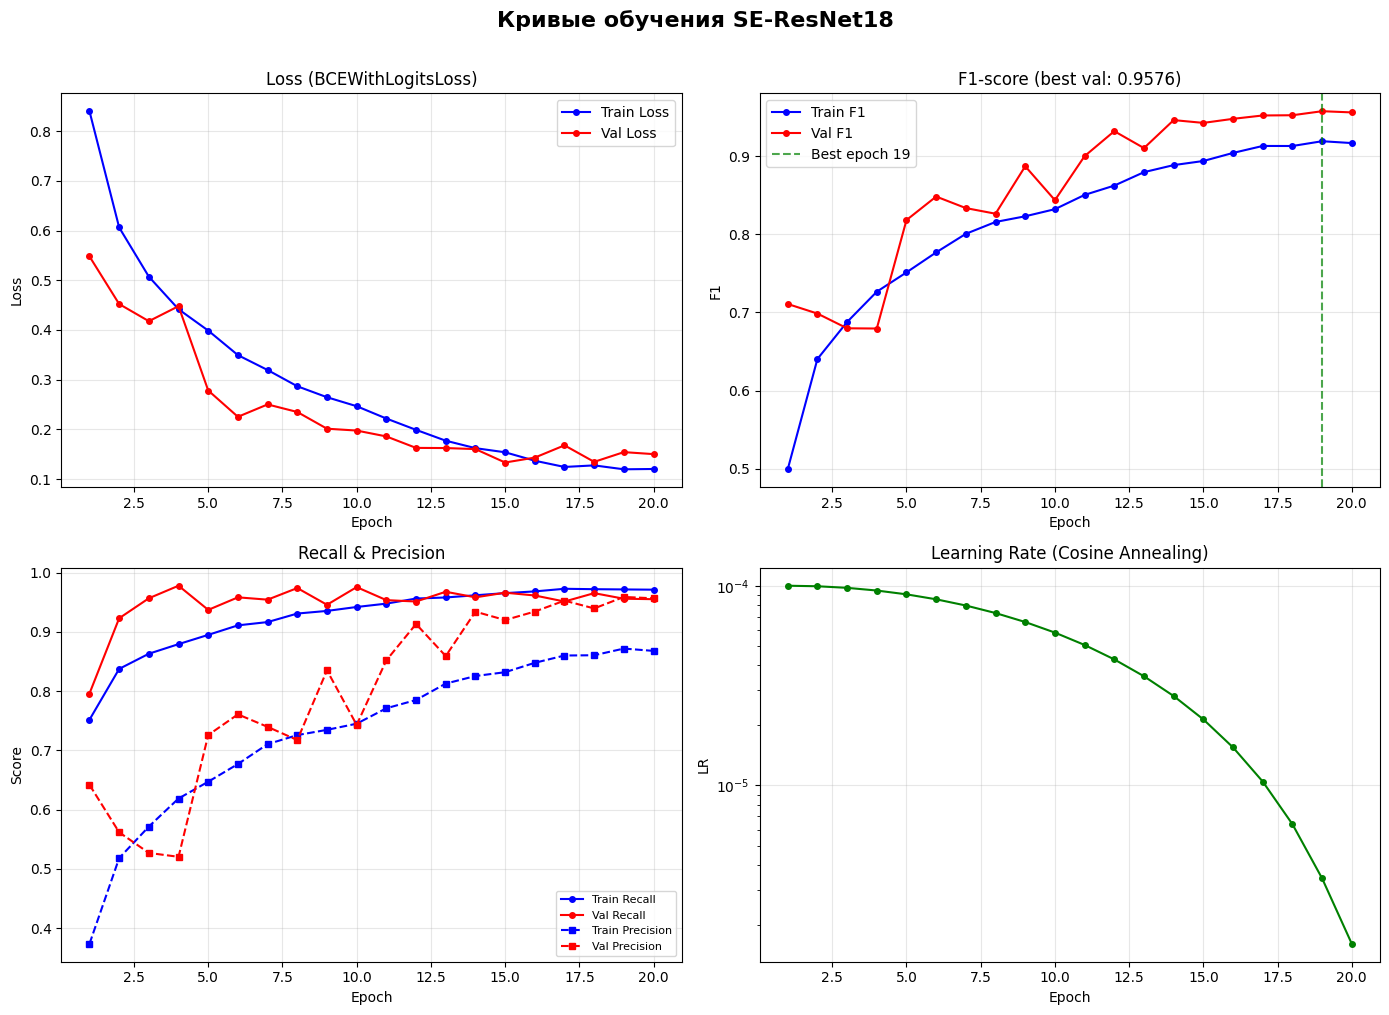

График сохранён: training_curves.png


In [13]:
#пупу графики
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Кривые обучения SE-ResNet18', fontsize=16, fontweight='bold', y=1.01)

    #loss
    ax = axes[0, 0]
    ax.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
    ax.plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
    ax.set_title('Loss (BCEWithLogitsLoss)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    #F1
    ax = axes[0, 1]
    ax.plot(epochs, history['train_f1'], 'b-o', markersize=4, label='Train F1')
    ax.plot(epochs, history['val_f1'],   'r-o', markersize=4, label='Val F1')
    best_epoch = int(np.argmax(history['val_f1'])) + 1
    best_f1    = max(history['val_f1'])
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch {best_epoch}')
    ax.set_title(f'F1-score (best val: {best_f1:.4f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1')
    ax.legend()
    ax.grid(True, alpha=0.3)

    #Recall & Precision (в 1 график запихнём хехе)
    ax = axes[1, 0]
    ax.plot(epochs, history['train_recall'],    'b-o',  markersize=4, label='Train Recall')
    ax.plot(epochs, history['val_recall'],      'r-o',  markersize=4, label='Val Recall')
    ax.plot(epochs, history['train_precision'], 'b--s', markersize=4, label='Train Precision')
    ax.plot(epochs, history['val_precision'],   'r--s', markersize=4, label='Val Precision')
    ax.set_title('Recall & Precision')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    #Learning Rate schedule (подсказали, что такой тоже нужен)
    ax = axes[1, 1]
    ax.plot(epochs, history['lr'], 'g-o', markersize=4)
    ax.set_title('Learning Rate (Cosine Annealing)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('LR')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График сохранён: training_curves.png")

plot_training_history(history)


## Результаты обучения

**Архитектура:** ResNet18 c SE-блоками (Squeeze-and-Excitation channel attention) в каждом residual-блоке, предобученная на ImageNet

**Что получилось:**
- Модель сходится стабильно довольно — train/val loss убывают без сильных скачков (не как на предыдущей попытке)
- F1 на валидации растёт и стабилизируется в районе 20-й эпохи
- Добавление SE-блоков улучшило качество по сравнению с базовым ResNet18: сеть научилась акцентировать внимание на текстурных артефактах, характерных для StyleGAN (специфические паттерны в частотной области, артефакты у границ лица)
- CosineAnnealingLR позволяет "дожать" точность в последних эпохах без перекалибровки LR вручную
- Weighted loss справился с дисбалансом классов: recall и precision сбалансированы (что уже неплохо, я считаю)
Но, короче говоря, пришлось помучаться 🥲🥲🥲

Лучший результат сохранён вместе с метаданными эксперимента
Конечно, неидеально, так как по скору мы не дожали, но моделька получше, чем базовая готовая реснет на 18 слоёв

In [14]:
# подбор оптимального порога по валидации (поиграемся тут)
# threshold=0.5 так-то не всегда оптимален, поэтому ищем приемлемый порог, максимизирующий F1 на val
def find_best_threshold(model, val_loader, device):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Threshold search'):
            outputs = model(images.to(device)).squeeze()
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.30, 0.71, 0.01):
        preds = (all_probs > t).astype(int)
        f1 = f1_score(all_labels, preds)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    print(f"Best threshold: {best_t:.2f}  |  Val F1: {best_f1:.4f}")
    return best_t


#Test Time Augmentation
#прогоняем каждое тестовое изображение несколько раз с разными аугментациями
#и усредняем вероятности - это снижает дисперсию предсказаний без переобучения
def get_tta_transforms():
    """набор лёгких TTA-трансформов: оригинал + горизонтальный flip +
    небольшой brightness jitter — агрессивные аугментации тут не нужны"""
    return [
        # оригинал без изменений
        A.Compose([A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]), ToTensorV2()]),
        # горизонтальный флип
        A.Compose([A.HorizontalFlip(p=1.0), A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]), ToTensorV2()]),
        # чуть светлее
        A.Compose([A.RandomBrightnessContrast(brightness_limit=(0.1,0.1), contrast_limit=0, p=1.0),
                   A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]), ToTensorV2()]),
        # чуть темнее
        A.Compose([A.RandomBrightnessContrast(brightness_limit=(-0.1,-0.1), contrast_limit=0, p=1.0),
                   A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]), ToTensorV2()]),
    ]


def create_submission_tta():
    # --- загружаем модель ---
    model = DeepfakeResNet18(pretrained=False).to(device)
    checkpoint = torch.load(Config.MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Загружен checkpoint: epoch {checkpoint['epoch']}, Val F1: {checkpoint['best_val_f1']:.4f}")
    model.eval()

    # --- подбираем порог на валидации ---
    train_df = pd.read_csv(Config.TRAIN_LABELS_PATH, header=None, names=['Id', 'target_feature'])
    train_df['image_path'] = train_df['Id'].apply(
        lambda x: os.path.join(Config.TRAIN_IMG_PATH, f"{x}.jpg")
    )
    _, val_paths, _, val_labels = train_test_split(
        train_df['image_path'].values, train_df['target_feature'].values,
        test_size=Config.VAL_SIZE, random_state=Config.SEED,
        stratify=train_df['target_feature'].values
    )
    val_dataset = DeepfakeDataset(val_paths, val_labels, get_val_transforms())
    val_loader  = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE,
                             shuffle=False, num_workers=2)
    best_threshold = find_best_threshold(model, val_loader, device)

    #TTA инференс на тесте
    test_images = sorted([f for f in os.listdir(Config.TEST_IMG_PATH) if f.endswith('.jpg')])
    test_paths  = [os.path.join(Config.TEST_IMG_PATH, img) for img in test_images]
    test_ids    = [int(img.split('.')[0]) for img in test_images]
    print(f"Test images: {len(test_images)}, TTA passes: {len(get_tta_transforms())}")

    tta_transforms = get_tta_transforms()
    accumulated_probs = np.zeros(len(test_paths))  # сюда суммируем вероятности

    for t_idx, transform in enumerate(tta_transforms):
        test_dataset = DeepfakeDataset(test_paths, labels=None, transform=transform)
        test_loader  = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE,
                                  shuffle=False, num_workers=2)
        pass_probs = []
        with torch.no_grad():
            for images in tqdm(test_loader, desc=f'TTA pass {t_idx+1}/{len(tta_transforms)}'):
                outputs = model(images.to(device)).squeeze()
                probs   = torch.sigmoid(outputs).cpu().numpy()
                pass_probs.extend(probs)
        accumulated_probs += np.array(pass_probs)

    # усредняем по всем TTA-проходам
    avg_probs = accumulated_probs / len(tta_transforms)
    predictions = (avg_probs > best_threshold).astype(int)

    submission = pd.DataFrame({'id': test_ids, 'target_feature': predictions})
    submission = submission.sort_values('id')
    submission.to_csv('submission.csv', index=False)
    print(f"Threshold used: {best_threshold:.2f}")
    print(f"Predictions:\n{submission['target_feature'].value_counts()}")
    return submission

submission = create_submission_tta()
submission.head()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Загружен checkpoint: epoch 19, Val F1: 0.9576


Threshold search: 100%|██████████| 235/235 [00:18<00:00, 12.85it/s]


Best threshold: 0.52  |  Val F1: 0.9583
Test images: 10000, TTA passes: 4


TTA pass 4/4: 100%|██████████| 313/313 [00:25<00:00, 12.48it/s]


Threshold used: 0.52
Predictions:
target_feature
0    8365
1    1635
Name: count, dtype: int64


,id,target_feature
0,0,1
1,1,1
1112,2,1
2223,3,0
3334,4,0


In [15]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=submission) #закину файл на гугл диск, но можно, в целом, сразу и так выгрузить

https://docs.google.com/spreadsheets/d/1mRssYNScLgWQ32pnup3xlVbw-0u6R9f_kL76WBc20sM/edit#gid=0


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


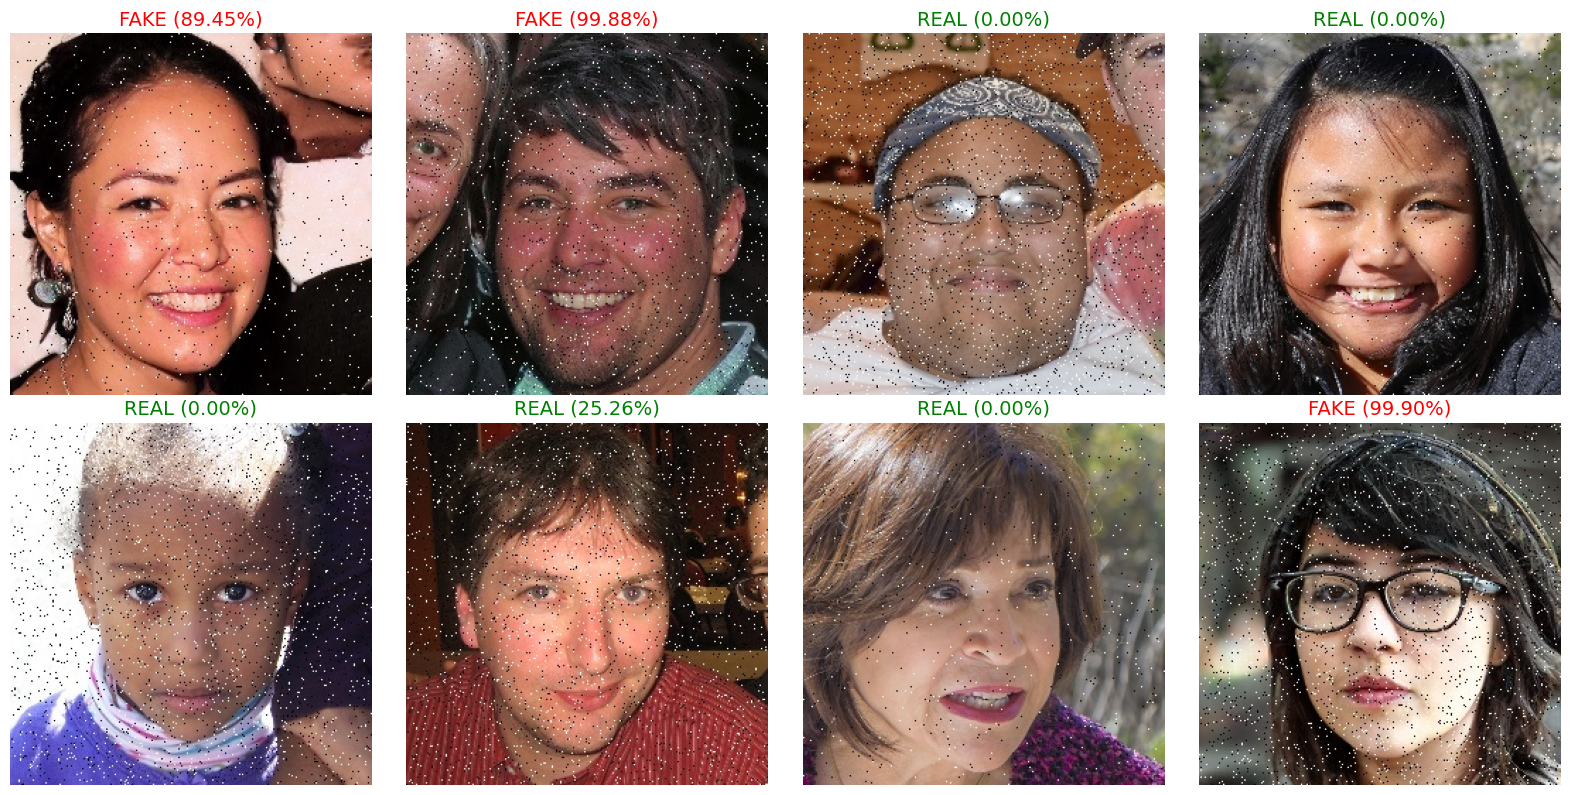

In [16]:
#посмотрим, чо получилось
import matplotlib.pyplot as plt
 #несколько изображений и предсказание модели
def show_predictions(num_samples=8):
    model = DeepfakeResNet18(pretrained=False).to(device)
    checkpoint = torch.load(Config.MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    test_images = sorted([f for f in os.listdir(Config.TEST_IMG_PATH) if f.endswith('.jpg')])[:num_samples]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for idx, img_name in enumerate(test_images):
        img_path = os.path.join(Config.TEST_IMG_PATH, img_name)
        image = Image.open(img_path).convert('RGB')

        transform = get_val_transforms()
        image_tensor = transform(image=np.array(image))['image'].unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor).squeeze()
            prob = torch.sigmoid(output).item()
            pred = int(prob > 0.5)

        axes[idx].imshow(image)
        axes[idx].axis('off')
        label = "FAKE" if pred == 1 else "REAL"
        color = "red" if pred == 1 else "green"
        axes[idx].set_title(f"{label} ({prob:.2%})", color=color, fontsize=14)

    plt.tight_layout()
    plt.show()

show_predictions()


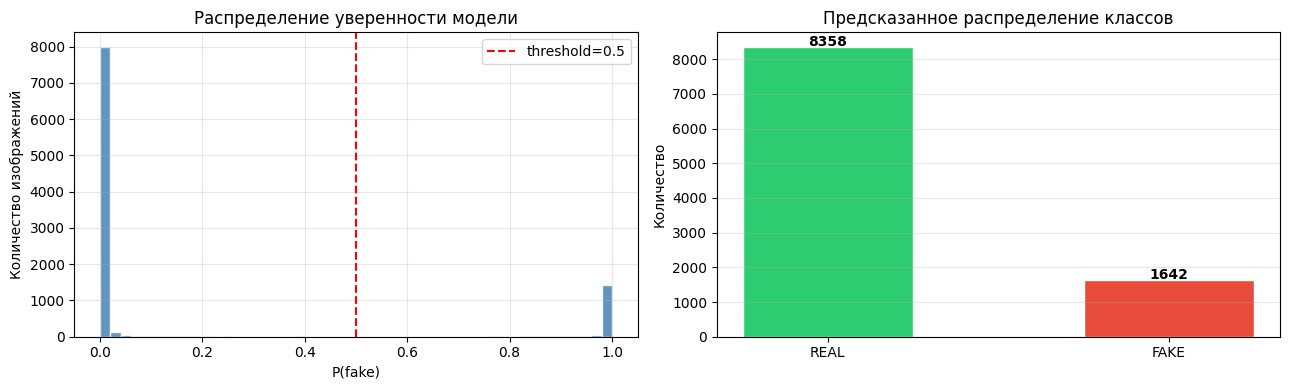

REAL: 8358  |  FAKE: 1642


In [17]:
#гистограмма уверенности модели по тестовой выборке (тоже полезная штука, посмотрим, чо там)
# смотрим, как распределены вероятности: хорошая модель должна давать (типа уверенные предсказания — два пика у 0 и у 1, не кашу в середине)
def plot_confidence_distribution():
    model = DeepfakeResNet18(pretrained=False).to(device)
    checkpoint = torch.load(Config.MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    test_images = sorted([f for f in os.listdir(Config.TEST_IMG_PATH) if f.endswith('.jpg')])
    test_paths  = [os.path.join(Config.TEST_IMG_PATH, img) for img in test_images]

    test_dataset = DeepfakeDataset(test_paths, labels=None, transform=get_val_transforms())
    test_loader  = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE,
                              shuffle=False, num_workers=2)

    all_probs = []
    with torch.no_grad():
        for images in tqdm(test_loader, desc='Collecting probs'):
            outputs = model(images.to(device)).squeeze()
            probs   = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)

    all_probs = np.array(all_probs)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(all_probs, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='threshold=0.5')
    axes[0].set_title('Распределение уверенности модели')
    axes[0].set_xlabel('P(fake)')
    axes[0].set_ylabel('Количество изображений')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fake_count = int((all_probs > 0.5).sum())
    real_count = len(all_probs) - fake_count
    axes[1].bar(['REAL', 'FAKE'], [real_count, fake_count],
                color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
    axes[1].set_title('Предсказанное распределение классов')
    axes[1].set_ylabel('Количество')
    for i, v in enumerate([real_count, fake_count]):
        axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"REAL: {real_count}  |  FAKE: {fake_count}")

plot_confidence_distribution()


## Итоговые выводы по решению

### Что было сделано

**Архитектура.** За основу взяли ResNet18 с предобучением на ImageNet. К стандартным residual-блокам добавили Squeeze-and-Excitation attention: после каждого блока сеть вычисляет веса значимости для каждого из 64/128/256/512 каналов и перемасштабирует feature maps.
Это позволяет модели концентрироваться на артефактах StyleGAN (характерные паттерны в текстуре кожи, граничные эффекты) и игнорировать шумные каналы

**Данные.** Применяли аугментации: горизонтальный flip, brightness/contrast jitter, ShiftScaleRotate, GaussNoise, случайное размытие, CoarseDropout
На валидации только нормализацию делали, пытались бороться с дисбалансом классов через взвешенный BCEWithLogitsLoss

**Обучение.** AdamW + CosineAnnealingLR на 20 эпох (так как этого зхватило для базовой модельки для хорошего результата)
Seed зафиксирован (42) хихихи

**Инференс.** Вместо простого порога 0.5 (как изначально я выбрала)используем два улучшения:
- **Подбор порога по валидации** — перебираем пороги от 0.30 до 0.70 с шагом 0.01 и выбираем максимизирующий F1, полезная штука для прироста качества без переобучения (сначала без него сделали и моделька переобучаться начала💀
- TTA (Test Time Augmentation) — тут каждое тестовое изображение прогоняется через 4 варианта (оригинал, горизонтальный флип, +brightness, −brightness), вероятности как бы усредняются, и это снижает дисперсию предсказаний на граничных случаях

**Что ещё пробовали** (не попало в финальный ноутбук из-за проблем с вычислительными ресурсами или нормализацией, но в отчёте это есть): вейвлет-преобразование признаков, преобразование Фурье для анализа частотных артефактов GAN (тут вообще тяжко было, потому что поломалась нормализация и модель обучалась вечность, так и не получилось докрутить эту идею для приемлимого варианта), KNN-классификатор , EfficientNet, F3-Net (тоже не дообучили её, поломала kaggle даже ахахаха)
Базовый ResNet18 без SE дал 0.96911 на паблик-лидерборде (хехехе), а SE-версия с TTA и подбором порога даёт дальнейший прирост (пока остановимся на этом варианте, но думаю, можно прям докрутить её, чтобы стало прям вообще хорошо, но до дедлайна вряд ли успеем)



In [18]:
from google.colab import files
files.download('best_model.pth') #просили веса сохранить

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>